In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import os
from dotenv import load_dotenv
load_dotenv()
GEMINI_API = os.getenv('GEMINI_API') 

In [2]:
# Class for Structured Output

class ReviewSentiment(BaseModel):
    sentiment: Literal["positive", 'negative'] = Field(description=("Check weather the user review is positive or negative."))

class DiagnosisOutput(BaseModel):
    issue_type: Literal['UX' , "Performance" , 'Bug' , 'Support' , "Other"] = Field(
        description="The category of the issue mentioned in the issue"
    )
    tone: Literal["angry", 'frustrated', 'disappointed', 'calm'] = Field(
        description="The emotional tone expressed by the user"
    )
    urgency: Literal['low', 'medium', "high"] = Field(
        description="How urgent or critical the issue appears to be"
    )

# State of Graph
class ReviewState(TypedDict):
    review: str
    sentiment: str
    diagnosis: DiagnosisOutput
    review_responce: str

In [3]:
llm = ChatGoogleGenerativeAI(api_key = GEMINI_API, model = "gemini-3.1-flash-lite")
review_sentiment_llm = llm.with_structured_output(ReviewSentiment)
diagnosis_output_llm = llm.with_structured_output(DiagnosisOutput)

In [39]:
def analyze_sentiment(state: ReviewState) -> ReviewState:
    review = state['review']
    prompt = f"""
For the following review find out the sentiment\n{review}
"""
    return {"sentiment": review_sentiment_llm.invoke(prompt).sentiment}

def run_diagnosis(state: ReviewState) -> ReviewState:
    review = state['review']
    prompt = f"""
Diagnose this negative, return issue_type, tone and urgency.\n\n{review}
"""    
    return {"diagnosis": diagnosis_output_llm.invoke(prompt)}

def reply_to_positive_review(state: ReviewState) -> ReviewState:
    review = state['review']
    prompt = f"""
Write a warm thankyou message in the responce to this review\n\n{review}
"""
    return {'review_responce': llm.invoke(prompt).content[0].get('text')}

def reply_to_negative_review(state: ReviewState) -> ReviewState:
    review = state['review']
    diagnosis: DiagnosisOutput = state['diagnosis']

    prompt = f"""
You are a support assistant.
The user had a {diagnosis.issue_type} issue, sounded {diagnosis.tone} and makked urgency as {diagnosis.urgency}.
Write an empathetic, helpful resolution message.
This is the original review user posted: {review}
"""
    
    return {"review_responce": llm.invoke(prompt).content[0].get('text')}

def check_sentiment_result(state: ReviewState) -> Literal['reply_to_positive_review', 'run_diagnosis']:
    sentiment = state['sentiment']
    if sentiment == "positive":
        print(f"sentiment {sentiment} in positive if block")
        return "reply_to_positive_review"
    else:
        print(f"sentiment {sentiment} in negative if block")
        return "run_diagnosis"

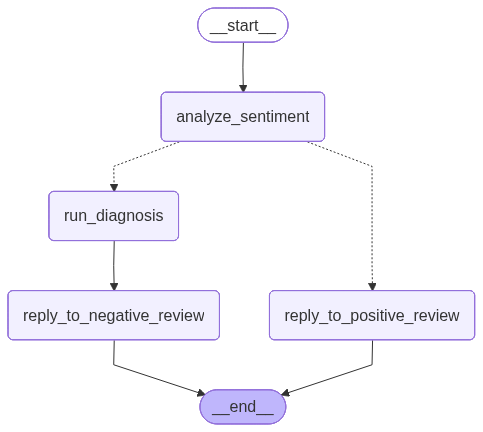

In [40]:
graph = StateGraph(ReviewState)


# Add nodes
graph.add_node("analyze_sentiment", analyze_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('reply_to_positive_review', reply_to_positive_review)
graph.add_node('reply_to_negative_review', reply_to_negative_review)


## Add Edges
graph.add_edge(START, 'analyze_sentiment')
graph.add_conditional_edges('analyze_sentiment', check_sentiment_result)
graph.add_edge("run_diagnosis", "reply_to_negative_review")
graph.add_edge("reply_to_negative_review", END)
graph.add_edge("reply_to_positive_review", END)

workflow = graph.compile()
workflow

In [41]:
reviews = [
    "Absolutely love this app. It's fast, intuitive, and has made my daily workflow much easier. Everything works exactly as expected.",

    "This website is frustrating to use. Pages load slowly, features are buggy, and the overall experience feels unfinished.",

    "The design is beautiful, navigation is smooth, and all the extra features are excellent. Unfortunately, the core functionality—the search feature—is inaccurate and often fails to find relevant results, which makes the app hard to rely on."
]

In [42]:
combined_final_states = []
for review in reviews:
    final_state = workflow.invoke({'review': review})
    combined_final_states.append(final_state)
    print("Got results and appended")
    break

sentiment positive in positive if block
Got results and appended


In [43]:
combined_final_states

[{'review': "Absolutely love this app. It's fast, intuitive, and has made my daily workflow much easier. Everything works exactly as expected.",
  'sentiment': 'positive',
  'review_responce': 'Here are a few options, depending on the tone you’d like to set:\n\n**Option 1: Warm and professional (Best for general use)**\n"Thank you so much for the wonderful review! We’re thrilled to hear that the app has become a helpful part of your daily workflow. Knowing that you find it fast and intuitive truly makes our day. Thanks for being part of our community!"\n\n**Option 2: Personal and appreciative**\n"We are so happy to hear that you’re enjoying the app! We designed it specifically to help streamline workflows, so it’s incredibly rewarding to know it’s working exactly as you need it to. Thank you for your support and for taking the time to share your experience!"\n\n**Option 3: Short and sweet**\n"Thanks a million for the kind words! We’re delighted to hear the app is making your daily task